In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import pandas_ta as ta


In [132]:
PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

CSV_PATH = "EURUSD_Candlestick_5_M_ASK_30.09.2019-30.09.2022.csv"

#N_ROWS = 30000

N_ROWS = None

BARS = 20
D_FRAC = 0.3
SLCOEF = 1.0
TPSL_RATIO = 1.0

TRAIN_SIZE = 5000
TEST_SIZE = 2500
EMBARGO = BARS

PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

MAX_ATR_RANK = 0.80
MIN_TREND_STRENGTH = 0.50
MAX_VOL_RATIO = 1.80
USE_VOL_RATIO_FILTER = True

In [133]:
# =========================
# LOAD DATA
# =========================

#df = pd.read_csv(CSV_PATH)
df = pd.read_csv(CSV_PATH)

if N_ROWS is not None:
    df = df.loc[:N_ROWS].copy()

#df = df.reset_index(drop=True)
df = df.loc[:N_ROWS].copy().reset_index(drop=True)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).reset_index(drop=True)

In [134]:
df["ret_3"] = df["Close"].pct_change(3)
df["ret_6"] = df["Close"].pct_change(6)
df["ret_12"] = df["Close"].pct_change(12)

df["ema_50"] = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()

df["trend_filter"] = (df["ema_50"] > df["ema_200"]).astype(int)

df["alpha_momentum"] = (
    df["ret_3"]
    + df["ret_6"]
    + df["ret_12"]
)

In [135]:
signal = (
    (df["trend_filter"] == 1)
    & (df["alpha_momentum"] > df["alpha_momentum"].rolling(500).quantile(0.70))
)

In [136]:
df["ema_50"] = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()
df["rsi_14"] = ta.rsi(df["Close"], length=14)

df["uptrend"] = df["ema_50"] > df["ema_200"]

signal = (
    df["uptrend"]
    & (df["rsi_14"] < 40)
    & (df["Close"] > df["ema_200"])
)

In [137]:
df["range_20"] = df["High"].rolling(20).max() - df["Low"].rolling(20).min()
df["range_100"] = df["High"].rolling(100).max() - df["Low"].rolling(100).min()

df["compression"] = df["range_20"] / df["range_100"]

df["breakout_high"] = df["High"].rolling(20).max().shift(1)

signal = (
    (df["compression"] < df["compression"].rolling(500).quantile(0.25))
    & (df["Close"] > df["breakout_high"])
)

In [138]:
df["Gmt time"] = pd.to_datetime(df["Gmt time"])
df["hour"] = df["Gmt time"].dt.hour
df["minute"] = df["Gmt time"].dt.minute

df["london_session"] = df["hour"].between(7, 11)
df["ny_overlap"] = df["hour"].between(12, 16)

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_5718/2193257230.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S.%f format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Gmt time"] = pd.to_datetime(df["Gmt time"])


In [139]:
session_filter = df["london_session"] | df["ny_overlap"]

In [140]:
df["ret_1"] = df["Close"].pct_change()

df["ema_50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["ema_200"] = df["Close"].ewm(span=200, adjust=False).mean()

df["rsi_14"] = ta.rsi(df["Close"], length=14)

df["atr"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)
df["atr_pct"] = df["atr"] / df["Close"]
df["atr_rank"] = df["atr_pct"].rolling(500).rank(pct=True)

df["uptrend"] = df["ema_50"] > df["ema_200"]
df["pullback"] = df["rsi_14"] < 40
df["vol_ok"] = df["atr_rank"] < 0.80

alpha_signal = (
    df["uptrend"]
    & df["pullback"]
    & df["vol_ok"]
).astype(int)

In [141]:
df["alpha_signal"] = alpha_signal

events = df[df["alpha_signal"] == 1].copy()

print(events.shape)
display(events.head())

(11811, 30)


,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,minute,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal
556,2019-10-01 22:20:00,1.09315,1.09321,1.09304,1.09310,230.59,-0.000137,-0.000210,-0.000329,1.093303,...,20,False,False,-0.000055,0.000227,0.000208,0.334,True,True,1
570,2019-10-01 23:30:00,1.09312,1.09312,1.09300,1.09305,195.76,-0.000027,-0.000091,-0.000091,1.093239,...,30,False,False,-0.000064,0.000147,0.000135,0.112,True,True,1
606,2019-10-02 02:30:00,1.09365,1.09368,1.09335,1.09336,350.05,-0.000256,-0.000274,-0.000421,1.093634,...,30,False,False,-0.000265,0.000148,0.000135,0.134,True,True,1
626,2019-10-02 04:10:00,1.09349,1.09349,1.09330,1.09338,403.73,-0.000256,-0.000320,-0.000146,1.093636,...,10,False,False,-0.000091,0.000136,0.000125,0.102,True,True,1
627,2019-10-02 04:15:00,1.09338,1.09344,1.09332,1.09341,328.56,-0.000219,-0.000265,-0.000201,1.093627,...,15,False,False,0.000027,0.000135,0.000124,0.100,True,True,1


In [142]:
META_BARS = 24

future_ret = (
    events["Close"]
    .shift(-META_BARS)
    / events["Close"]
    - 1
)

events["meta_label"] = (
    future_ret > 0.0005
).astype(int)

In [143]:
feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
]

In [144]:
events = events.dropna(subset=feature_cols + ["meta_label"]).reset_index(drop=True)

In [145]:
TRAIN_SIZE = 800
TEST_SIZE = 200
EMBARGO = META_BARS

In [146]:
print("Events:", len(events))
print("Need at least:", TRAIN_SIZE + EMBARGO + TEST_SIZE)

if len(events) < TRAIN_SIZE + EMBARGO + TEST_SIZE:
    raise ValueError(
        "Not enough alpha events. Reduce TRAIN_SIZE/TEST_SIZE or loosen alpha_signal."
    )

Events: 11811
Need at least: 1024


In [147]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import xgboost as xgb

results = []

n = len(events)

for start in range(
    0,
    n - TRAIN_SIZE - EMBARGO - TEST_SIZE + 1,
    TEST_SIZE
):

    # =========================
    # WALK-FORWARD SPLITS
    # =========================

    train = events.iloc[start : start + TRAIN_SIZE]

    test = events.iloc[
        start + TRAIN_SIZE + EMBARGO :
        start + TRAIN_SIZE + EMBARGO + TEST_SIZE
    ]

    # =========================
    # FEATURES / LABELS
    # =========================

    X_train_raw = train[feature_cols]
    y_train = train["meta_label"]

    X_test_raw = test[feature_cols]
    y_test = test["meta_label"]

    # =========================
    # SCALING
    # =========================

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # =========================
    # PCA
    # =========================

    pca = PCA(n_components=0.95)

    X_train = pca.fit_transform(X_train_scaled)
    X_test = pca.transform(X_test_scaled)

    # =========================
    # XGBOOST
    # =========================

    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(X_train, y_train)

    # =========================
    # PREDICTIONS
    # =========================

    proba = clf.predict_proba(X_test)[:, 1]

    signal = (proba >= 0.55).astype(int)

    # =========================
    # STORE RESULTS
    # =========================

    fold_df = pd.DataFrame({
        "y_true": y_test.values,
        "proba": proba,
        "signal": signal,
    })

    results.append(fold_df)

    print(
        f"Fold done | "
        f"Train: {len(train)} | "
        f"Test: {len(test)} | "
        f"PCA comps: {pca.n_components_}"
    )

ml_results = pd.concat(results, ignore_index=True)

print(ml_results.head())

Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 5
Fold done | Train: 800 | Test: 200 | PCA comps: 5
Fold done | Train: 800 | Test: 200 | PCA comps: 5
Fold done | Train: 800 | Test: 200 | PCA comps: 5
Fold done | Train: 800 | Test: 200 | PCA comps: 5
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4


In [148]:
train

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,meta_label
10600,2022-06-24 07:20:00,1.05246,1.05277,1.05234,1.05269,1789.93,-0.000702,-0.000759,-0.000873,1.053557,...,True,False,0.000209,0.000429,0.000408,0.480,True,True,1,1
10601,2022-06-24 07:25:00,1.05267,1.05297,1.05245,1.05262,1377.90,-0.000285,-0.000816,-0.001025,1.053521,...,True,False,-0.000066,0.000436,0.000414,0.512,True,True,1,1
10602,2022-06-24 07:30:00,1.05262,1.05292,1.05247,1.05275,925.28,0.000266,-0.000541,-0.000750,1.053490,...,True,False,0.000124,0.000437,0.000415,0.514,True,True,1,1
10603,2022-06-24 07:35:00,1.05276,1.05320,1.05272,1.05276,1031.89,0.000066,-0.000636,-0.001082,1.053462,...,True,False,0.000009,0.000440,0.000418,0.524,True,True,1,1
10604,2022-06-24 07:45:00,1.05290,1.05295,1.05240,1.05253,1401.16,-0.000209,0.000057,-0.001082,1.053406,...,True,False,-0.000399,0.000444,0.000422,0.534,True,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,2022-08-24 01:40:00,0.99487,0.99497,0.99463,0.99482,918.57,0.000010,-0.000161,-0.001054,0.996027,...,False,False,-0.000060,0.000367,0.000369,0.362,True,True,1,1
11396,2022-08-24 16:40:00,0.99479,0.99495,0.99449,0.99465,1954.83,-0.000954,-0.001867,-0.002247,0.995238,...,False,True,-0.000141,0.000740,0.000744,0.776,True,True,1,1
11397,2022-08-25 00:00:00,0.99682,0.99682,0.99634,0.99643,839.55,-0.000391,-0.000582,-0.000261,0.996794,...,False,False,-0.000381,0.000208,0.000209,0.060,True,True,1,1
11398,2022-08-25 07:45:00,0.99991,0.99995,0.99955,0.99964,1724.25,-0.001069,-0.002057,-0.002485,1.000283,...,True,False,-0.000270,0.000662,0.000662,0.798,True,True,1,0


In [149]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[feature_cols])
X_test_scaled = scaler.transform(test[feature_cols])

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

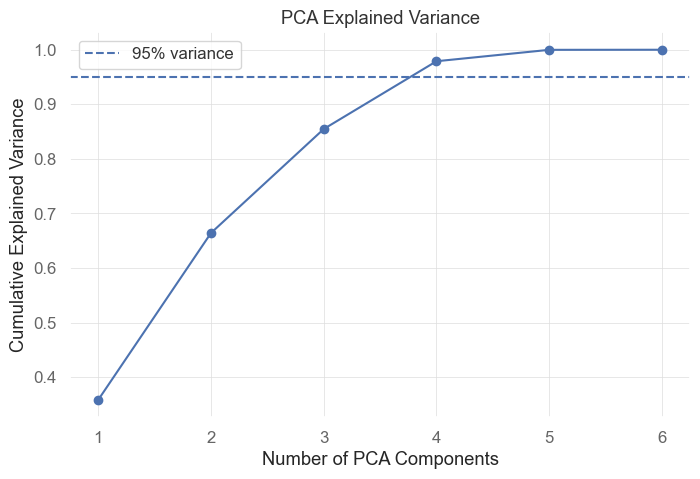

In [150]:
pca_full = PCA()

pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.legend()

plt.show()

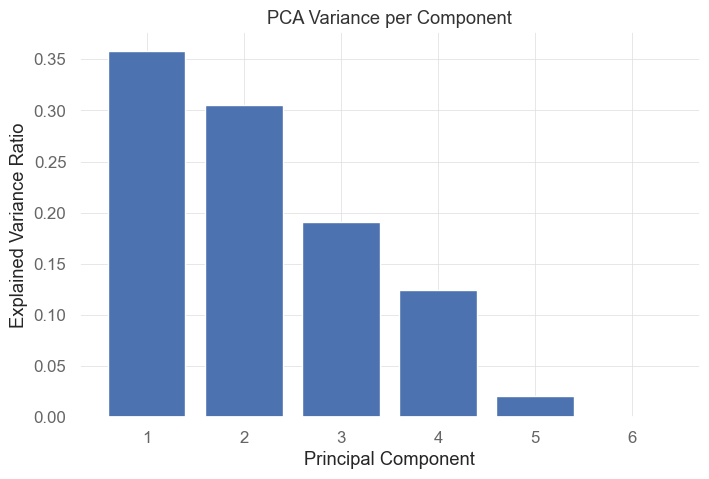

In [151]:
explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained)+1),
    explained
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Variance per Component")

plt.grid(True)

plt.show()

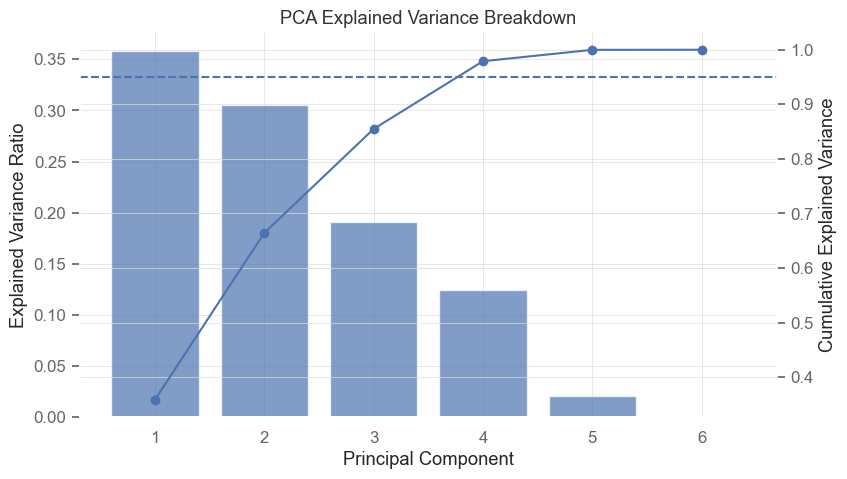

In [152]:
cum_var = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(
    range(1, len(explained)+1),
    explained,
    alpha=0.7,
    label="Individual"
)

ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()

ax2.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o",
    label="Cumulative"
)

ax2.axhline(0.95, linestyle="--")

ax2.set_ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance Breakdown")

plt.show()

In [153]:
loadings = pd.DataFrame(
    pca_full.components_,
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(len(feature_cols))]
)

display(loadings)

,ret_1,rsi_14,atr_pct,atr_rank,ema_50,ema_200
PC1,-0.129965,0.145509,0.336300,0.461956,0.565618,0.561704
PC2,-0.253961,-0.005499,0.601194,0.489890,-0.405620,-0.411728
PC3,0.635979,0.752152,0.099122,0.075716,-0.082787,-0.085946
PC4,0.716847,-0.642500,0.169963,0.206392,0.029119,0.031478
PC5,-0.016519,0.015795,-0.697570,0.705862,-0.094050,-0.076078
PC6,-0.001022,0.002930,0.012331,-0.005751,-0.706401,0.707675


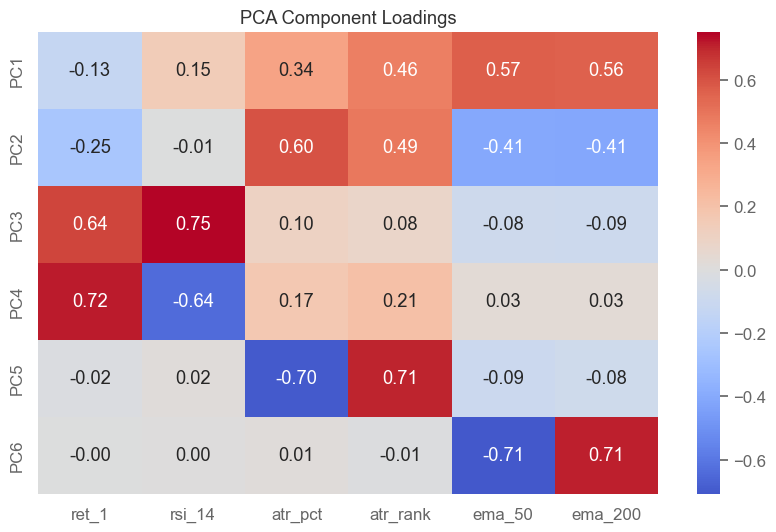

In [154]:
plt.figure(figsize=(10,6))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("PCA Component Loadings")

plt.show()

In [155]:
META_BARS = 24

future_ret = (
    events["Close"].shift(-META_BARS)
    / events["Close"]
    - 1
)

events["meta_label"] = (
    future_ret > 0.0005
).astype(int)

In [156]:
MIN_EVENT_GAP = META_BARS

events = events.iloc[
    np.arange(0, len(events), MIN_EVENT_GAP)
].copy()

In [157]:
# 1. Add new features to df FIRST

for k in [3, 6, 12, 24]:
    df[f"ret_{k}"] = df["Close"].pct_change(k)

df["dist_high_50"] = df["Close"] / df["High"].rolling(50).max()
df["dist_low_50"] = df["Close"] / df["Low"].rolling(50).min()

df["atr_change"] = df["atr_pct"].diff()

In [158]:
df.tail()

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,ret_24,dist_high_50,dist_low_50,atr_change
225081,2022-09-30 20:35:00,0.98028,0.98034,0.98001,0.98022,624.12,-0.000428,-0.000520,0.000398,0.979837,...,0.000491,0.000501,0.128,False,True,0,-0.000520,0.998594,1.002670,-0.000013
225082,2022-09-30 20:40:00,0.98023,0.98047,0.98007,0.98030,408.20,-0.000561,-0.000571,0.000082,0.979855,...,0.000485,0.000494,0.116,False,True,0,-0.000530,0.998676,1.002752,-0.000007
225083,2022-09-30 20:45:00,0.98026,0.98034,0.98019,0.98031,317.29,0.000031,-0.000438,0.000092,0.979873,...,0.000461,0.000470,0.092,False,True,0,-0.001151,0.998686,1.002762,-0.000024
225084,2022-09-30 20:50:00,0.98031,0.98067,0.97987,0.97999,1472.13,-0.000235,-0.000663,-0.000071,0.979878,...,0.000485,0.000495,0.116,False,True,0,-0.001060,0.998360,1.002352,0.000025
225085,2022-09-30 20:55:00,0.98000,0.98066,0.97993,0.98026,1068.81,-0.000041,-0.000602,0.000122,0.979893,...,0.000503,0.000513,0.144,False,True,0,-0.000459,0.998635,1.002342,0.000018


In [159]:
feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",
    "dist_high_50",
    "dist_low_50",
    "atr_change",
]

missing = [c for c in feature_cols if c not in df.columns]
print("Missing from df:", missing)

Missing from df: []


In [160]:
feature_cols = [

    # =========================
    # ORIGINAL FEATURES
    # =========================

    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",

    # =========================
    # MULTI-HORIZON MOMENTUM
    # =========================

    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",

    # =========================
    # DISTANCE FROM EXTREMES
    # =========================

    "dist_high_50",
    "dist_low_50",

    # =========================
    # VOLATILITY ACCELERATION
    # =========================

    "atr_change",
]

In [161]:
events.tail()

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,meta_label
11712,2022-09-28 23:15:00,0.97200,0.97205,0.97164,0.97166,1066.02,-0.000710,-0.000617,-0.001285,0.972568,...,False,False,-0.000329,0.000300,0.000309,0.068,True,True,1,0
11736,2022-09-29 01:15:00,0.96887,0.96939,0.96877,0.96911,1270.78,-0.000165,-0.000578,-0.001165,0.971026,...,False,False,0.000248,0.000520,0.000537,0.278,True,True,1,0
11760,2022-09-29 05:50:00,0.96605,0.96642,0.96570,0.96597,3575.68,-0.001375,-0.002334,-0.003024,0.968448,...,False,False,-0.000072,0.000521,0.000539,0.366,True,True,1,1
11784,2022-09-30 03:55:00,0.98016,0.98025,0.97991,0.98000,2341.01,-0.000571,-0.000163,-0.000989,0.981085,...,False,False,-0.000173,0.000495,0.000505,0.196,True,True,1,0
11808,2022-09-30 10:55:00,0.97609,0.97623,0.97573,0.97619,2688.33,-0.001105,-0.000266,-0.003644,0.980258,...,True,False,0.000102,0.000953,0.000976,0.714,True,True,1,0


In [162]:
# feature_cols = [
#     "ret_1",
#     "rsi_14",
#     "atr_pct",
#     "atr_rank",
#     "ema_50",
#     "ema_200",
#     "ret_3",
#     "ret_6",
#     "ret_12",
#     "ret_24",
#     "dist_high_50",
#     "dist_low_50",
#     "atr_change",
#     "london_session",
#     "ny_overlap",
# ]

# missing = [c for c in feature_cols if c not in events.columns]
# print("Missing:", missing)

# events = events.dropna(
#     subset=feature_cols + ["meta_label"]
# ).reset_index(drop=True)

# print("Events:", len(events))
# print(events["meta_label"].value_counts())
# print("Base rate:", events["meta_label"].mean())

In [163]:
# 1. Add missing features to df

df["ret_24"] = df["Close"].pct_change(24)

df["dist_high_50"] = df["Close"] / df["High"].rolling(50).max()
df["dist_low_50"] = df["Close"] / df["Low"].rolling(50).min()

df["atr_change"] = df["atr_pct"].diff()

In [164]:
# 2. Recreate events from updated df

events = df[df["alpha_signal"] == 1].copy()

META_BARS = 24

future_ret = events["Close"].shift(-META_BARS) / events["Close"] - 1
events["meta_label"] = (future_ret > 0.0005).astype(int)

In [165]:
events = events.dropna(
    subset=feature_cols + ["meta_label"]
).reset_index(drop=True)

In [166]:
# 3. Define features and clean

feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",
    "dist_high_50",
    "dist_low_50",
    "atr_change",
    "london_session",
    "ny_overlap",
]

missing = [c for c in feature_cols if c not in events.columns]
print("Missing:", missing)

events = events.dropna(
    subset=feature_cols + ["meta_label"]
).reset_index(drop=True)

print("Events:", len(events))
print(events["meta_label"].value_counts())
print("Base rate:", events["meta_label"].mean())

Missing: []
Events: 11811
meta_label
0    6542
1    5269
Name: count, dtype: int64
Base rate: 0.44610955888578446


In [167]:
TRAIN_SIZE = 800
TEST_SIZE = 200
EMBARGO = 24

In [168]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
)

import xgboost as xgb

results = []

n = len(events)

fold = 0

for start in range(
    0,
    n - TRAIN_SIZE - EMBARGO - TEST_SIZE + 1,
    TEST_SIZE
):

    fold += 1

    # =========================
    # WALK-FORWARD SPLITS
    # =========================

    train = events.iloc[start : start + TRAIN_SIZE]

    test = events.iloc[
        start + TRAIN_SIZE + EMBARGO :
        start + TRAIN_SIZE + EMBARGO + TEST_SIZE
    ]

    # =========================
    # FEATURES / LABELS
    # =========================

    X_train_raw = train[feature_cols]
    y_train = train["meta_label"]

    X_test_raw = test[feature_cols]
    y_test = test["meta_label"]

    # =========================
    # SCALING
    # =========================

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # =========================
    # PCA
    # =========================

    pca = PCA(n_components=0.95)

    X_train = pca.fit_transform(X_train_scaled)
    X_test = pca.transform(X_test_scaled)

    # =========================
    # MODEL
    # =========================

    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(X_train, y_train)

    # =========================
    # PREDICTIONS
    # =========================

    proba = clf.predict_proba(X_test)[:,1]

    # signal = (proba > 0.55).astype(int)
    TOP_K_FRAC = 0.10   # approve top 10% of candidate events in each test fold

    k = max(1, int(len(proba) * TOP_K_FRAC))

    signal = np.zeros(len(proba), dtype=int)

    top_idx = np.argsort(proba)[-k:]

    signal[top_idx] = 1

    # =========================
    # STORE RESULTS
    # =========================

    fold_df = pd.DataFrame({
        "fold": fold,
        "time": test["Gmt time"].values,
        "close": test["Close"].values,
        "y_true": y_test.values,
        "proba": proba,
        "signal": signal,
    })

    results.append(fold_df)

    print(
        f"Fold {fold} | "
        f"Train {len(train)} | "
        f"Test {len(test)} | "
        f"PCA comps {pca.n_components_}"
    )

ml_results = pd.concat(results, ignore_index=True)

print(ml_results.head())

Fold 1 | Train 800 | Test 200 | PCA comps 10
Fold 2 | Train 800 | Test 200 | PCA comps 10
Fold 3 | Train 800 | Test 200 | PCA comps 10
Fold 4 | Train 800 | Test 200 | PCA comps 10
Fold 5 | Train 800 | Test 200 | PCA comps 10
Fold 6 | Train 800 | Test 200 | PCA comps 10
Fold 7 | Train 800 | Test 200 | PCA comps 10
Fold 8 | Train 800 | Test 200 | PCA comps 10
Fold 9 | Train 800 | Test 200 | PCA comps 10
Fold 10 | Train 800 | Test 200 | PCA comps 10
Fold 11 | Train 800 | Test 200 | PCA comps 11
Fold 12 | Train 800 | Test 200 | PCA comps 10
Fold 13 | Train 800 | Test 200 | PCA comps 10
Fold 14 | Train 800 | Test 200 | PCA comps 10
Fold 15 | Train 800 | Test 200 | PCA comps 10
Fold 16 | Train 800 | Test 200 | PCA comps 10
Fold 17 | Train 800 | Test 200 | PCA comps 10
Fold 18 | Train 800 | Test 200 | PCA comps 10
Fold 19 | Train 800 | Test 200 | PCA comps 10
Fold 20 | Train 800 | Test 200 | PCA comps 10
Fold 21 | Train 800 | Test 200 | PCA comps 10
Fold 22 | Train 800 | Test 200 | PCA comps 

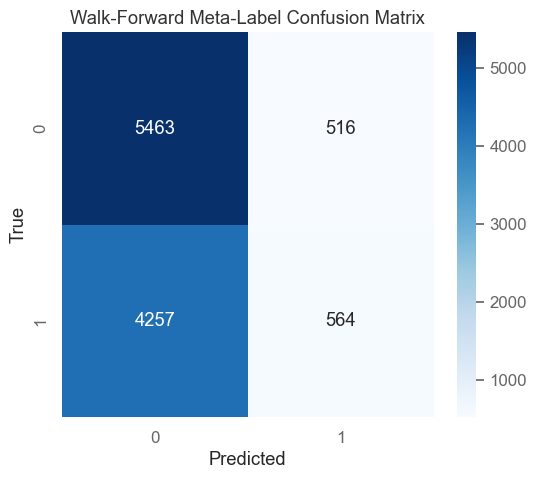

              precision    recall  f1-score   support

           0       0.56      0.91      0.70      5979
           1       0.52      0.12      0.19      4821

    accuracy                           0.56     10800
   macro avg       0.54      0.52      0.44     10800
weighted avg       0.54      0.56      0.47     10800



In [169]:
cm = confusion_matrix(
    ml_results["y_true"],
    ml_results["signal"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Walk-Forward Meta-Label Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

print(classification_report(
    ml_results["y_true"],
    ml_results["signal"],
    zero_division=0
))

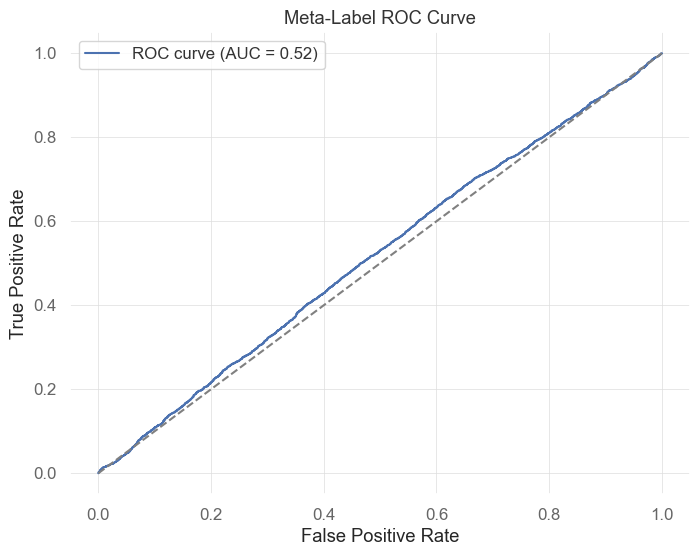

In [170]:
#plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(ml_results["y_true"], ml_results["proba"])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Meta-Label ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

In [171]:
print(ml_results.columns.tolist())

['fold', 'time', 'close', 'y_true', 'proba', 'signal']


In [172]:
HOLD_BARS = 24

ml_results["future_ret"] = (
    ml_results["close"].shift(-HOLD_BARS)
    / ml_results["close"]
    - 1
)

In [173]:
ml_results["strategy_ret"] = (
    ml_results["future_ret"]
    * ml_results["signal"]
)

In [174]:
SPREAD_COST = 0.00005

ml_results["net_ret"] = (
    ml_results["strategy_ret"]
    - SPREAD_COST * ml_results["signal"]
)

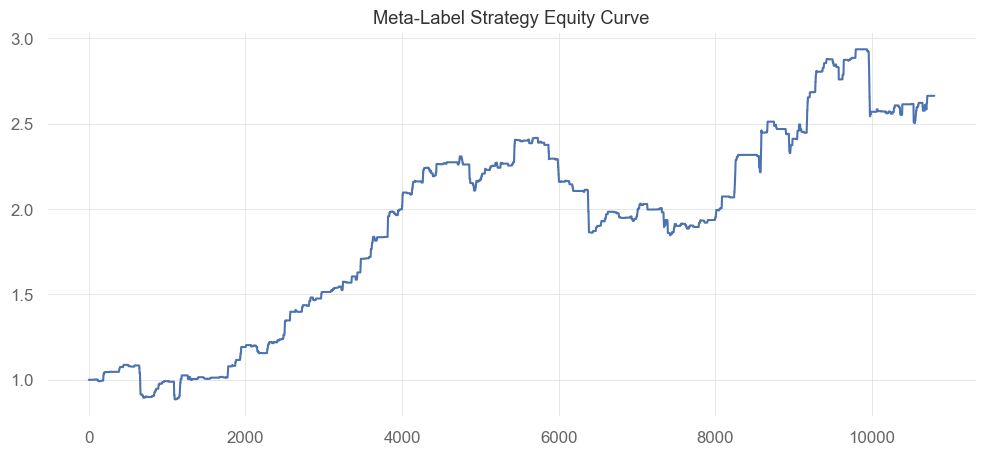

In [175]:
equity = (
    1 + ml_results["net_ret"].fillna(0)
).cumprod()

equity.plot(figsize=(12,5))
plt.grid(True)
plt.title("Meta-Label Strategy Equity Curve")
plt.show()

In [176]:
rets = ml_results["net_ret"].dropna()

sharpe = (
    rets.mean()
    / rets.std()
) * np.sqrt(252 * 24 * 12)

print("Sharpe:", sharpe)

Sharpe: 13.452799381945029


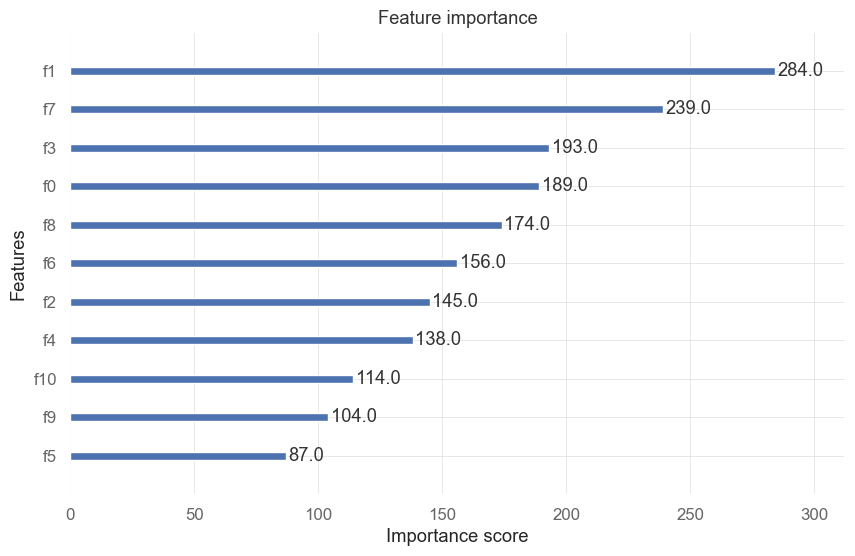

In [177]:
xgb.plot_importance(clf)
plt.show()


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2019-12-12
End Period                 2022-09-16
Risk-Free Rate             0.0%
Time in Market             10.0%

Cumulative Return          166.35%
CAGR﹪                     2.31%

Sharpe                     0.79
Prob. Sharpe Ratio         100.0%
Smart Sharpe               0.48
Sortino                    1.13
Smart Sortino              0.69
Sortino/√2                 0.8
Smart Sortino/√2           0.49
Omega                      1.62

Max Drawdown               -23.6%
Max DD Date                2021-11-23
Max DD Period Start        2021-06-03
Max DD Period End          2022-03-09
Longest DD Days            280
Volatility (ann.)          2.94%
Calmar                     0.1
Skew                       -2.57
Kurtosis                   88.01
Ulcer Performance I

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2021-06-03,2021-11-23,2022-03-09,280,-23.600652,-22.947014
2,2020-01-21,2020-03-18,2020-05-21,122,-18.567629,-18.405170
3,2022-07-07,2022-08-23,2022-09-16,71,-14.740495,-14.377206
4,2021-03-12,2021-03-29,2021-05-07,57,-8.660952,-8.353319
5,2022-03-18,2022-04-14,2022-05-13,57,-7.343839,-7.056127


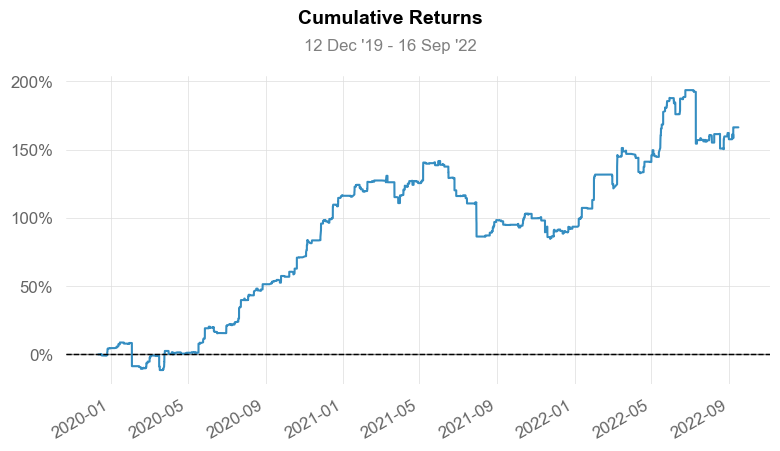

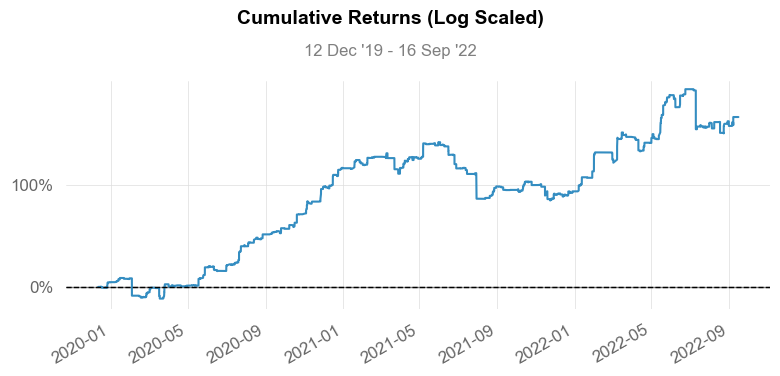

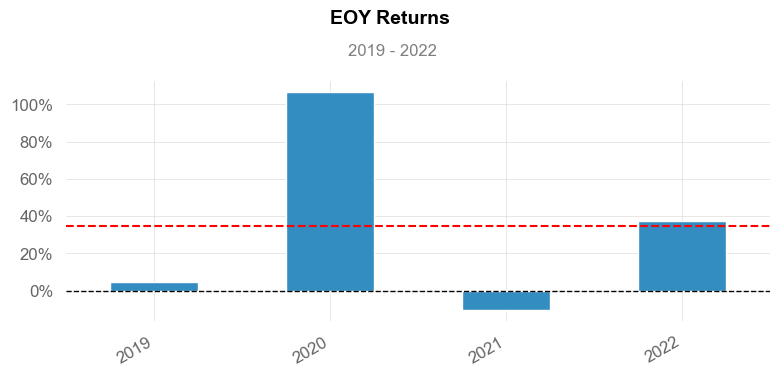

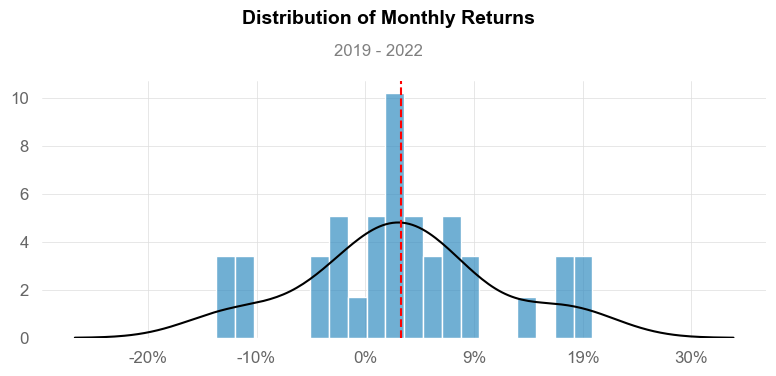

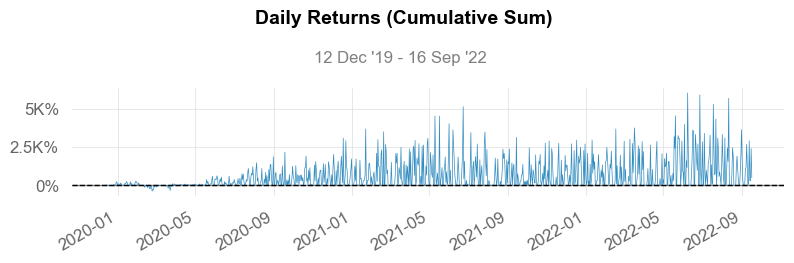

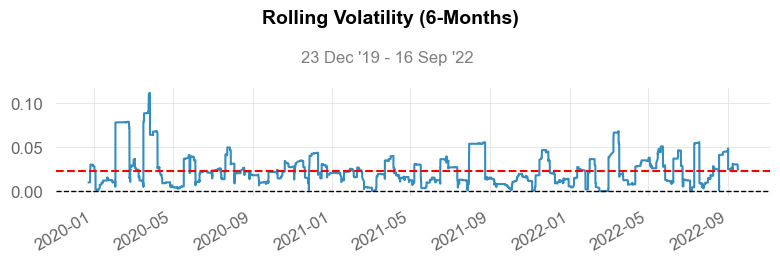

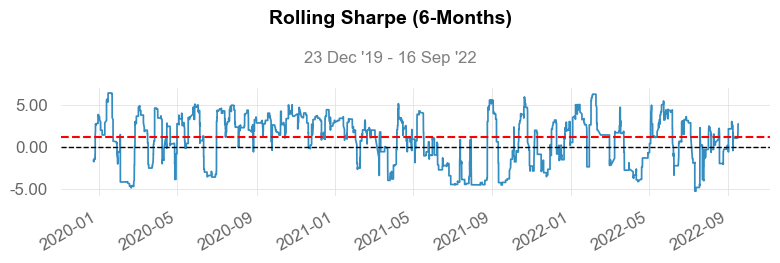

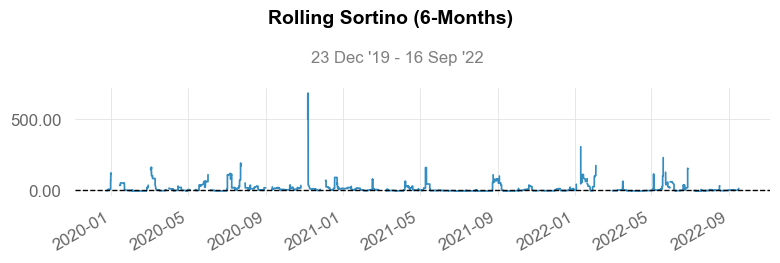

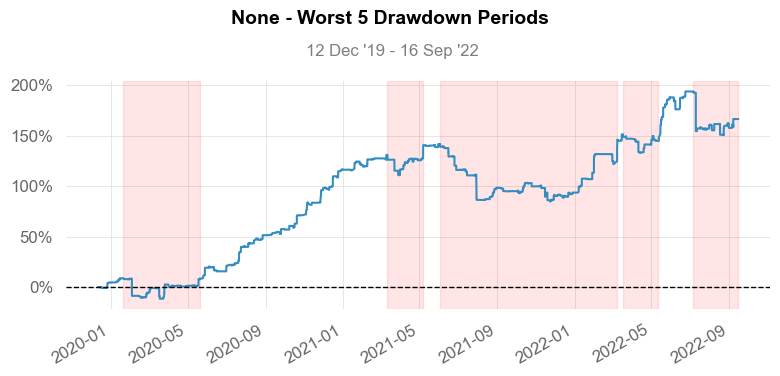

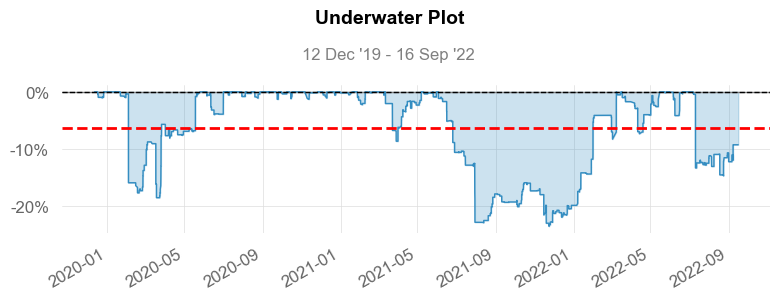

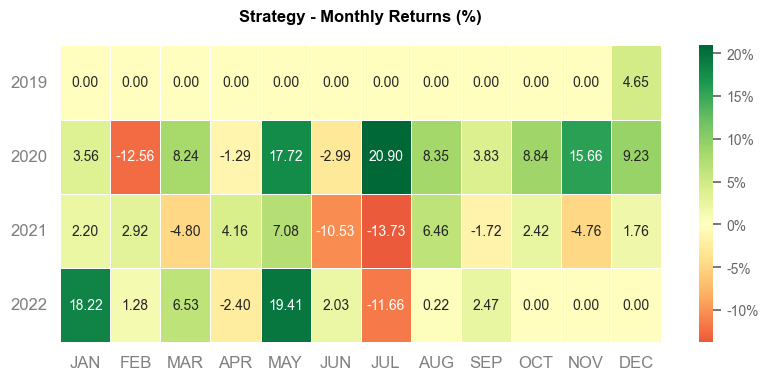

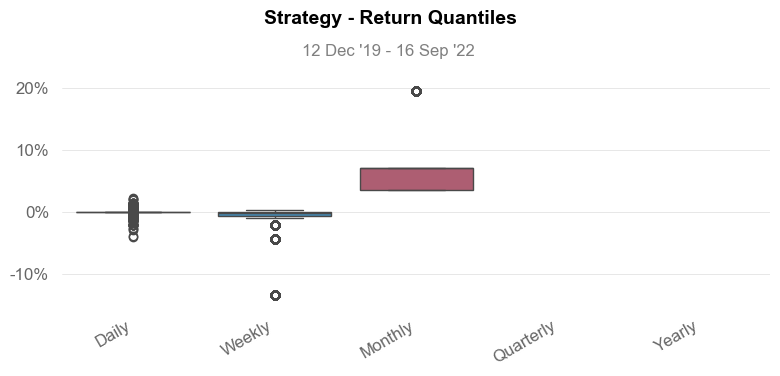

In [178]:
import quantstats as qs

returns = ml_results["net_ret"].fillna(0)

# If you have timestamps:
returns.index = pd.to_datetime(ml_results["time"])

qs.reports.full(
    returns,
    output="meta_label_strategy_report.html",
    title="EURUSD Meta-Label Strategy"
)

In [179]:
from backtesting import Backtest, Strategy

# ============================================================
# MAP WALK-FORWARD ML SIGNALS BACK TO RAW 5-MIN DATA
# ============================================================

df_bt = df.copy()

df_bt["Gmt time"] = pd.to_datetime(df_bt["Gmt time"])
ml_results["time"] = pd.to_datetime(ml_results["time"])

df_bt = df_bt.set_index("Gmt time")
ml_sig = ml_results.set_index("time")["signal"]

df_bt["Signal"] = 0
df_bt.loc[df_bt.index.intersection(ml_sig.index), "Signal"] = ml_sig.loc[
    df_bt.index.intersection(ml_sig.index)
].values

df_bt = df_bt[["Open", "High", "Low", "Close", "Volume", "Signal"]].copy()

print(df_bt["Signal"].value_counts())

Signal
0    224006
1      1080
Name: count, dtype: int64


In [180]:
# ============================================================
# BACKTESTING.PY STRATEGY
# ============================================================

HOLD_BARS = 24  # 24 x 5-min = 2 hours

class MLMetaLongStrategy(Strategy):
    hold_bars = HOLD_BARS

    def init(self):
        self.signal = self.I(lambda x: x, self.data.Signal)
        self.entry_bar = None

    def next(self):
        # enter only if no open position
        if not self.position and self.signal[-1] == 1:
            self.buy()
            self.entry_bar = len(self.data.Close)

        # time-based exit
        if self.position and self.entry_bar is not None:
            if len(self.data.Close) - self.entry_bar >= self.hold_bars:
                self.position.close()
                self.entry_bar = None

In [181]:
bt = Backtest(
    df_bt,
    MLMetaLongStrategy,
    cash=10_000,
    commission=0.00005,   # rough FX cost proxy; adjust
    margin=1/30,
    exclusive_orders=True,
    finalize_trades=True,
)

stats = bt.run()
display(stats)

bt.plot()

Backtest.run:   0%|          | 0/225085 [00:00<?, ?bar/s]

Start                     2019-09-30 00:00:00
End                       2022-09-30 20:55:00
Duration                   1096 days 20:55:00
Exposure Time [%]                     4.74263
Equity Final [$]                  13685.46402
Equity Peak [$]                   13921.39008
Commissions [$]                   13536.10759
Return [%]                           36.85464
Buy & Hold Return [%]               -10.40162
Return (Ann.) [%]                     8.77501
Volatility (Ann.) [%]                50.69163
CAGR [%]                              7.47436
Sharpe Ratio                          0.17311
Sortino Ratio                           0.331
Calmar Ratio                          0.22994
Alpha [%]                            49.59603
Beta                                  1.22494
Max. Drawdown [%]                   -38.16292
Avg. Drawdown [%]                    -5.30099
Max. Drawdown Duration      598 days 17:00:00
Avg. Drawdown Duration       29 days 03:03:00
# Trades                          

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '4h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p1730', ...)